In [1]:
import os
import json
import pprint

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
line_separator = '-' * 100

In [3]:
rootpath = "/Users/adrian/data" # Update this to your actual root path

def read_results_file(file_path):
    with open(file_path, 'r') as f:
        return json.load(f)

# 1. How often does the LLM respond with 'I don't know'?

- Model based
- Question based 
- Entity based (TODO)

## 1.1 NaN Values Analysis (model based)  

### score = count of nan values / total answers

In [4]:
# score = count of nan values / total answers
# 1) collect nan information 'nan_matrix' for global heatmap (loop over all the models / runs)
# 2) collect nan information 'nan_matrix_model_based' for model heatmap (loop over all runs)
# heatmap (entity language x prompt language)

entity_languages = []
prompt_languages = []
num_langs = 5
# entity_languages = ['pl','it','ru','de','en']
# prompt_languages = ['en','de','ru','it','pl']
# Initialize a 5x5 matrix to hold NaN percentages
nan_matrix = np.zeros((5, 5))
nan_matrix_model_based = {}

# Loop through entity and prompt languages to calculate NaN percentages
for i, entity_lang_path in enumerate(os.listdir(rootpath)):
    entity_language = entity_lang_path
    entity_languages.append(entity_language)

    for j, prompt_lang_path in enumerate(os.listdir(os.path.join(rootpath, entity_lang_path))):
        prompt_language = prompt_lang_path
        if i + j == num_langs - 1: prompt_languages.append(prompt_language)

        global_nan = 0
        global_total = 0
        
        # Loop through models and runs for the current entity and prompt language
        for model_name in os.listdir(os.path.join(rootpath, entity_lang_path, prompt_lang_path)):
            # Skip the folders that contain raw data
            if model_name in ['raw_data', 'merged']:
                continue
            
            # Initialize a 5x5 matrix to hold NaN percentages for each model
            if model_name not in nan_matrix_model_based:
                nan_matrix_model_based[model_name] = np.zeros((5, 5))  
                
            nan = 0
            total = 0
            
            # Loop through runs. For the same entity & related questions, each model inference three times with do_sample=True and outputs (same/different) results.  
            for run in os.listdir(os.path.join(rootpath, entity_lang_path, prompt_lang_path, model_name)):
                run_id = int(run.split('_')[1])
            
                for results_file_path in os.listdir(os.path.join(rootpath, entity_lang_path, prompt_lang_path, model_name, run)):
                    try:
                        results_json = read_results_file(os.path.join(rootpath, entity_lang_path, prompt_lang_path, model_name, run, results_file_path))
                    except:
                        print(f"Could not read result file: {results_file_path}")
                        continue
                        
                    entity_id = results_file_path.split(".")[0].split("_")[0]
                    assert results_file_path.split(".")[0].split("_")[-1] == prompt_language
                    assert results_json['raw_data']['authorLabel']['xml:lang'] == entity_language
                    
                    for k, v in results_json['outputs'].items():
                        
                        total += 1
                        
                        if isinstance(v, list):
                            if len(set(v)) == 1 and 'N/A' in v[0].strip():
                                nan += 1
                        elif isinstance(v, str):
                            if 'N/A' in v.strip():
                                nan += 1
                        else:
                            raise ValueError("The content is not string-based and list-based.")
                            
            # (each model) Calculate percentage of NaN values for the current entity and prompt language combination
            pct_nan = round((nan / total) * 100, 2)
            print(f"Percentage of NA for entity {entity_language} - prompt {prompt_language} ( {model_name} ) : {pct_nan}%")
            
            nan_matrix_model_based[model_name][i, num_langs - 1 - j] = pct_nan
        
            global_nan += nan
            global_total += total
            
        # Calculate percentage of NaN values for the current entity and prompt language combination
        global_pct_nan = round((global_nan / global_total) * 100, 2)
        print(line_separator)
        print(f"Percentage of NA for entity {entity_language} - prompt {prompt_language}: {global_pct_nan}%")
        print(line_separator)
        
        # Store the result in the matrix
        nan_matrix[i, num_langs - 1 - j] = global_pct_nan

Percentage of NA for entity pl - prompt pl ( llama3 ) : 5.31%
Percentage of NA for entity pl - prompt pl ( gemma ) : 2.96%
Percentage of NA for entity pl - prompt pl ( llama3_1_70b ) : 16.43%
Percentage of NA for entity pl - prompt pl ( llama3_1 ) : 12.56%
Percentage of NA for entity pl - prompt pl ( phi3_5 ) : 20.77%
Percentage of NA for entity pl - prompt pl ( mistral ) : 4.95%
----------------------------------------------------------------------------------------------------
Percentage of NA for entity pl - prompt pl: 10.54%
----------------------------------------------------------------------------------------------------
Percentage of NA for entity pl - prompt it ( llama3 ) : 3.86%
Percentage of NA for entity pl - prompt it ( gemma ) : 3.45%
Percentage of NA for entity pl - prompt it ( llama3_1_70b ) : 57.35%
Percentage of NA for entity pl - prompt it ( llama3_1 ) : 7.73%
Percentage of NA for entity pl - prompt it ( phi3_5 ) : 11.59%
Percentage of NA for entity pl - prompt it ( 

Percentage of NA for entity ru - prompt en ( llama3_1_70b ) : 19.54%
Percentage of NA for entity ru - prompt en ( llama3_1 ) : 3.14%
Percentage of NA for entity ru - prompt en ( phi3_5 ) : 3.07%
Percentage of NA for entity ru - prompt en ( mistral ) : 6.25%
----------------------------------------------------------------------------------------------------
Percentage of NA for entity ru - prompt en: 6.17%
----------------------------------------------------------------------------------------------------
Percentage of NA for entity de - prompt pl ( llama3 ) : 6.87%
Percentage of NA for entity de - prompt pl ( gemma ) : 2.8%
Percentage of NA for entity de - prompt pl ( llama3_1_70b ) : 53.23%
Percentage of NA for entity de - prompt pl ( llama3_1 ) : 32.57%
Percentage of NA for entity de - prompt pl ( phi3_5 ) : 12.98%
Percentage of NA for entity de - prompt pl ( mistral ) : 6.97%
----------------------------------------------------------------------------------------------------
Percent

### 1.1.1 NAN information Global Heatmap 

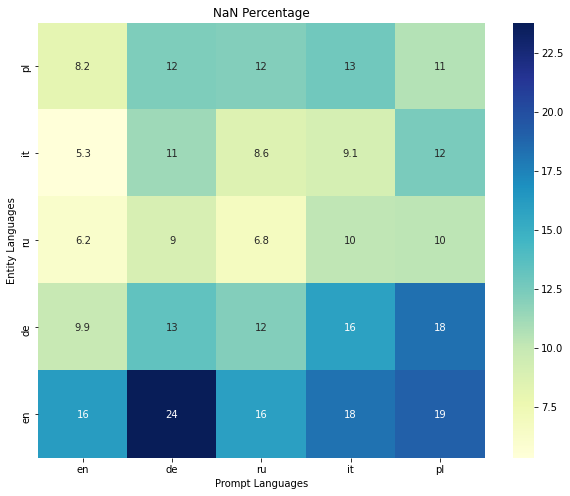

In [5]:
# Generate the heatmap for entity vs prompt languages (global)
plt.figure(figsize=(10, 8))
sns.heatmap(nan_matrix, annot=True, cmap="YlGnBu", xticklabels=prompt_languages, yticklabels=entity_languages)
plt.title("NaN Percentage")
plt.xlabel("Prompt Languages")
plt.ylabel("Entity Languages")

# Show the heatmap
plt.show()

### 1.1.2 NAN information Model Heatmaps 

The inference with the model llama3.1-70b used int4 precision, it may be one of the reasons with higher pct. of nan values.

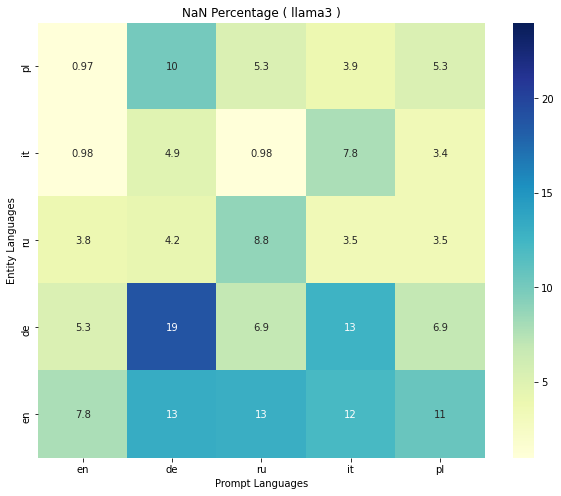

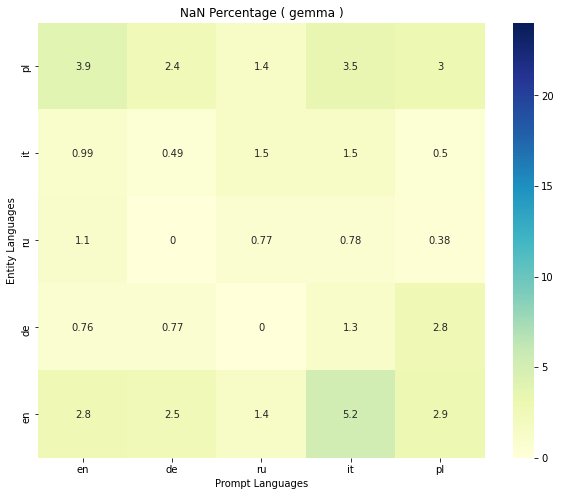

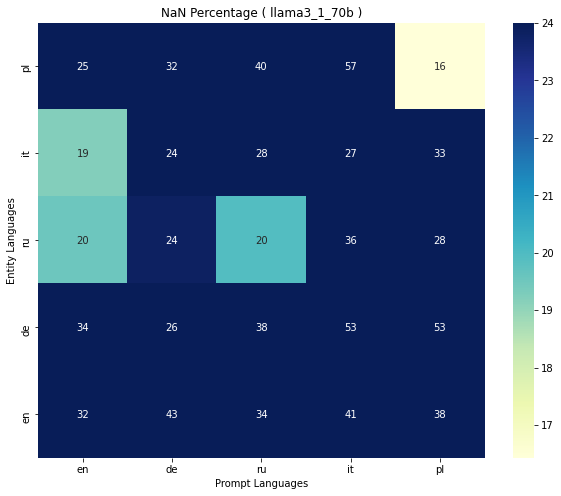

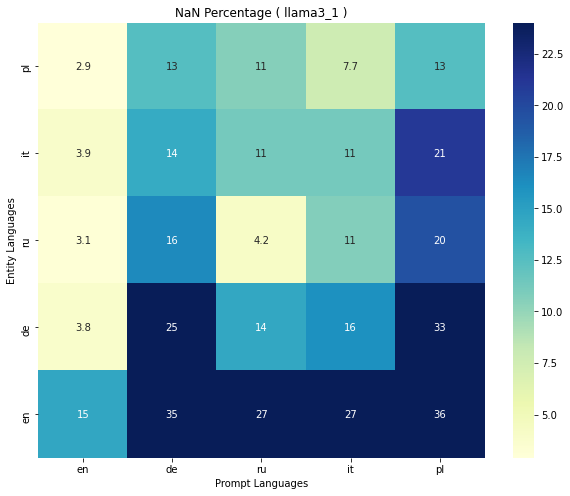

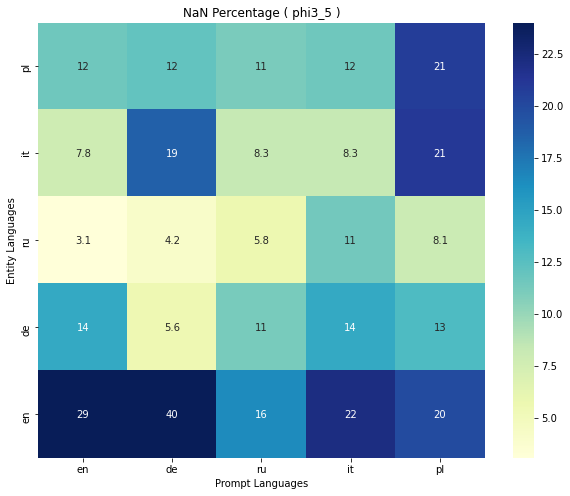

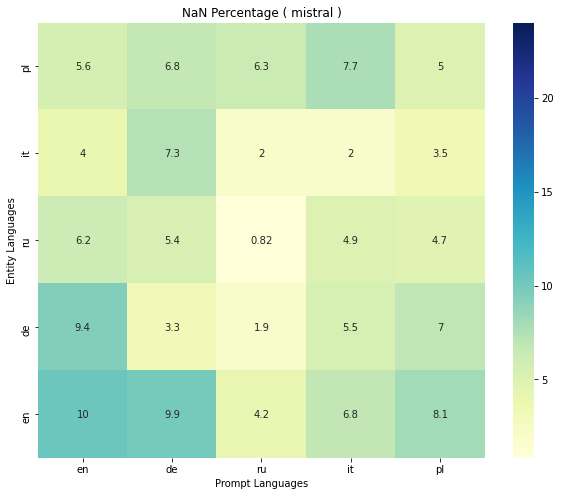

In [6]:
# Generate the heatmap for entity vs prompt languages (each model)
for model_name, nan_matrix_m in nan_matrix_model_based.items():

    plt.figure(figsize=(10, 8))
    sns.heatmap(nan_matrix_m, annot=True, vmax=24, cmap="YlGnBu", xticklabels=prompt_languages, yticklabels=entity_languages)
    plt.title(f"NaN Percentage ( { model_name } )")
    plt.xlabel("Prompt Languages")
    plt.ylabel("Entity Languages")

    # Show the heatmap
    plt.show()

## 1.2 NaN Values Analysis (question based)  

"Not available" means that the raw data files from wiki include empty fields (no ground truths are provided) so we do not inference these questions. 

In [7]:
# 3) collect nan information 'nan_matrix_question_based' for heatmap (loop over all the model / runs)
# "not available" means that the raw data from wiki have empty field (no ground truth) so we do not inference these questions. 

entity_languages = []
prompt_languages = []
num_langs = 5
num_questions = 13
# misalignments from raw data exist, some entities do not include 'dob'
labels_dict = {1: 'dob', 2: 'pobLabels', 3: 'birthNameLabels', 4: 'countryLabels', 5: 'spouseLabels', 6: 'writingLanguageLabels', 7: 'occupationLabels', 8: 'fowLabels', 9: 'ethnicGroupLabels', 10: 'employerLabels', 11: 'notableWorkLabels', 12: 'politicalPartyLabels', 13: 'awardReceivedLabels'}
# Initialize 5x5 matrices to hold NaN percentages for each question 
nan_matrix_question_based = { qid + 1 : np.zeros((5, 5)) for qid in range(num_questions)} 

# Loop through entity and prompt languages to calculate NaN percentages
for i, entity_lang_path in enumerate(os.listdir(rootpath)):
    entity_language = entity_lang_path
    entity_languages.append(entity_language)

    for j, prompt_lang_path in enumerate(os.listdir(os.path.join(rootpath, entity_lang_path))):
        prompt_language = prompt_lang_path
        if i + j == num_langs - 1: prompt_languages.append(prompt_language)

        global_nan = 0
        global_total = 0
        
        tmp_dict = { qid + 1 : {'total': 0, 'nan': 0} for qid in range(num_questions)}
        
        # Loop through models and runs for the current entity and prompt language
        for model_name in os.listdir(os.path.join(rootpath, entity_lang_path, prompt_lang_path)):
            # Skip the folders that contain raw data
            if model_name in ['raw_data', 'merged']:
                continue 
            
            # Loop through runs. For the same entity & related questions, each model inference three times with do_sample=True and outputs (same/different) results.  
            for run in os.listdir(os.path.join(rootpath, entity_lang_path, prompt_lang_path, model_name)):
                run_id = int(run.split('_')[1])
            
                for results_file_path in os.listdir(os.path.join(rootpath, entity_lang_path, prompt_lang_path, model_name, run)):
                    try:
                        results_json = read_results_file(os.path.join(rootpath, entity_lang_path, prompt_lang_path, model_name, run, results_file_path))
                    except:
                        print(f"Could not read result file: {results_file_path}")
                        continue
                        
                    entity_id = results_file_path.split(".")[0].split("_")[0]
                    assert results_file_path.split(".")[0].split("_")[-1] == prompt_language
                    assert results_json['raw_data']['authorLabel']['xml:lang'] == entity_language
# DEBUG                   
#                     for label, value in results_json['raw_data'].items():
#                         if value['idx'] in labels_dict:
#                             try:
#                                 assert label == labels_dict[ value['idx'] ]
#                             except:
#                                 print(label, labels_dict[ value['idx'] ])
#                         if value['idx'] != 0:
#                             labels_dict[ value['idx'] ] = label
                    
                    # Different than the global one, same idx may refer to different things in different entities'raw json files 
                    tmp_label_dict = { value['idx'] : label for label, value in results_json['raw_data'].items()}
                    
                    for idx, v in results_json['outputs'].items():
                        
                        # Binding to the global one
                        idx = int(idx)
                        label = tmp_label_dict[idx]
                        for key, value in labels_dict.items():
                            if value == label:
                                qid = key
                        
                        tmp_dict[qid]['total'] += 1
                        
                        if isinstance(v, list):
                            if len(set(v)) == 1 and 'N/A' in v[0].strip():
                                tmp_dict[qid]['nan'] += 1
                        elif isinstance(v, str):
                            if 'N/A' in v.strip():
                                tmp_dict[qid]['nan'] += 1
                        else:
                            raise ValueError("The content is not string-based and list-based.")
                            
        # pprint.pprint(tmp_dict)            
        for qid, v in tmp_dict.items():
            
            pct_nan = round((tmp_dict[qid]['nan'] / tmp_dict[qid]['total']) * 100, 2) if tmp_dict[qid]['total'] > 0 else 0
            nan_matrix_question_based[qid][i, num_langs - 1 - j] = pct_nan
            
            if tmp_dict[qid]['total'] != 0:
                print(f"Percentage of NA for entity {entity_language} - prompt {prompt_language} ( {qid}: {labels_dict[qid]} ) : {pct_nan}%")
            else:
                print(f"Percentage of NA for entity {entity_language} - prompt {prompt_language} ( {qid}: {labels_dict[qid]} ) : {pct_nan}% (not available)")

        global_nan = sum(v['nan'] for qid, v in tmp_dict.items())
        global_total = sum(v['total'] for qid, v in tmp_dict.items())

        # Calculate percentage of NaN values for the current entity and prompt language combination
        global_pct_nan = round((global_nan / global_total) * 100, 2)
        print(line_separator)
        print(f"Percentage of NA for entity {entity_language} - prompt {prompt_language}: {global_pct_nan}%")
        print(line_separator)

        # Store the result in the matrix
        nan_matrix[i, num_langs - 1 - j] = global_pct_nan

Percentage of NA for entity pl - prompt pl ( 1: dob ) : 15.56%
Percentage of NA for entity pl - prompt pl ( 2: pobLabels ) : 7.87%
Percentage of NA for entity pl - prompt pl ( 3: birthNameLabels ) : 5.56%
Percentage of NA for entity pl - prompt pl ( 4: countryLabels ) : 0.29%
Percentage of NA for entity pl - prompt pl ( 5: spouseLabels ) : 0% (not available)
Percentage of NA for entity pl - prompt pl ( 6: writingLanguageLabels ) : 0.0%
Percentage of NA for entity pl - prompt pl ( 7: occupationLabels ) : 7.84%
Percentage of NA for entity pl - prompt pl ( 8: fowLabels ) : 1.87%
Percentage of NA for entity pl - prompt pl ( 9: ethnicGroupLabels ) : 0% (not available)
Percentage of NA for entity pl - prompt pl ( 10: employerLabels ) : 52.34%
Percentage of NA for entity pl - prompt pl ( 11: notableWorkLabels ) : 0% (not available)
Percentage of NA for entity pl - prompt pl ( 12: politicalPartyLabels ) : 0% (not available)
Percentage of NA for entity pl - prompt pl ( 13: awardReceivedLabels )

Percentage of NA for entity ru - prompt pl ( 1: dob ) : 11.97%
Percentage of NA for entity ru - prompt pl ( 2: pobLabels ) : 7.25%
Percentage of NA for entity ru - prompt pl ( 3: birthNameLabels ) : 1.92%
Percentage of NA for entity ru - prompt pl ( 4: countryLabels ) : 2.38%
Percentage of NA for entity ru - prompt pl ( 5: spouseLabels ) : 0% (not available)
Percentage of NA for entity ru - prompt pl ( 6: writingLanguageLabels ) : 2.86%
Percentage of NA for entity ru - prompt pl ( 7: occupationLabels ) : 2.01%
Percentage of NA for entity ru - prompt pl ( 8: fowLabels ) : 0.0%
Percentage of NA for entity ru - prompt pl ( 9: ethnicGroupLabels ) : 2.94%
Percentage of NA for entity ru - prompt pl ( 10: employerLabels ) : 29.21%
Percentage of NA for entity ru - prompt pl ( 11: notableWorkLabels ) : 39.08%
Percentage of NA for entity ru - prompt pl ( 12: politicalPartyLabels ) : 66.67%
Percentage of NA for entity ru - prompt pl ( 13: awardReceivedLabels ) : 43.4%
----------------------------

Percentage of NA for entity de - prompt de ( 1: dob ) : 16.33%
Percentage of NA for entity de - prompt de ( 2: pobLabels ) : 14.81%
Percentage of NA for entity de - prompt de ( 3: birthNameLabels ) : 0% (not available)
Percentage of NA for entity de - prompt de ( 4: countryLabels ) : 3.59%
Percentage of NA for entity de - prompt de ( 5: spouseLabels ) : 27.78%
Percentage of NA for entity de - prompt de ( 6: writingLanguageLabels ) : 5.56%
Percentage of NA for entity de - prompt de ( 7: occupationLabels ) : 4.58%
Percentage of NA for entity de - prompt de ( 8: fowLabels ) : 5.66%
Percentage of NA for entity de - prompt de ( 9: ethnicGroupLabels ) : 0% (not available)
Percentage of NA for entity de - prompt de ( 10: employerLabels ) : 41.11%
Percentage of NA for entity de - prompt de ( 11: notableWorkLabels ) : 0% (not available)
Percentage of NA for entity de - prompt de ( 12: politicalPartyLabels ) : 27.78%
Percentage of NA for entity de - prompt de ( 13: awardReceivedLabels ) : 34.44%

### Code Validation (ignored)

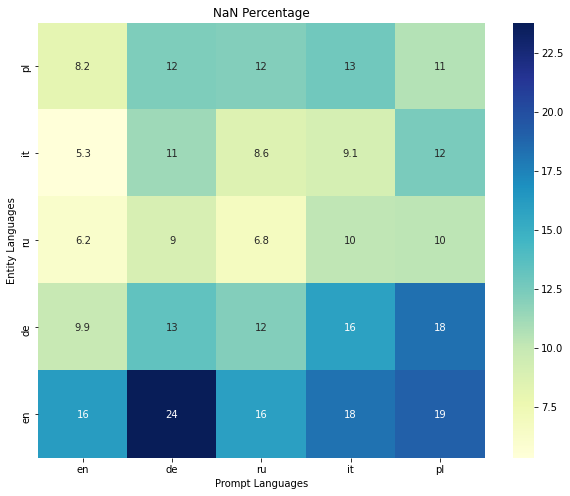

In [8]:
# Validate the code, it should be the same as 1.1.1 Global Heatmap
# Generate the heatmap for entity vs prompt languages (global)
plt.figure(figsize=(10, 8))
sns.heatmap(nan_matrix, annot=True, cmap="YlGnBu", xticklabels=prompt_languages, yticklabels=entity_languages)
plt.title("NaN Percentage")
plt.xlabel("Prompt Languages")
plt.ylabel("Entity Languages")

# Show the heatmap
plt.show()

### 1.2.1 NAN information Question Heatmaps 

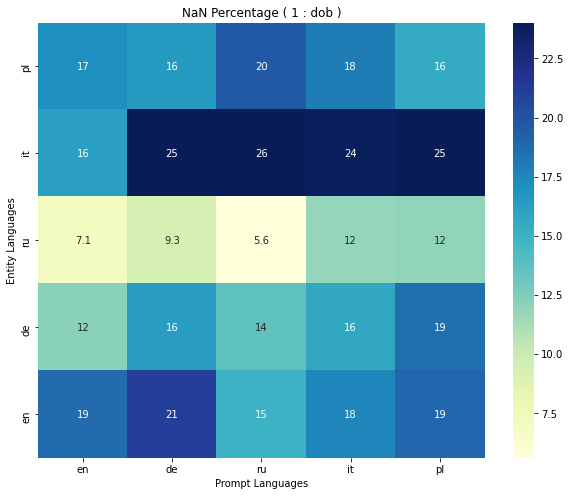

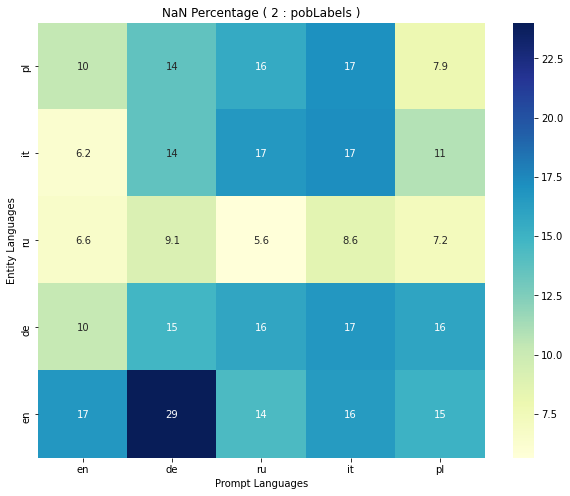

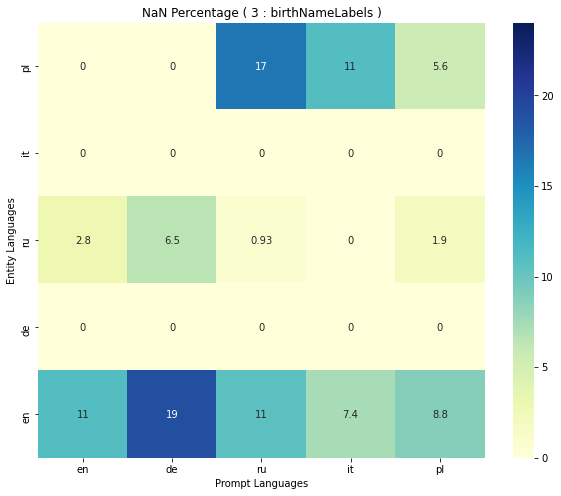

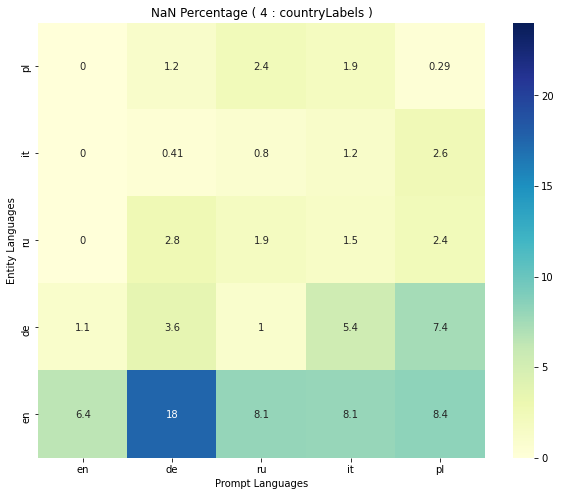

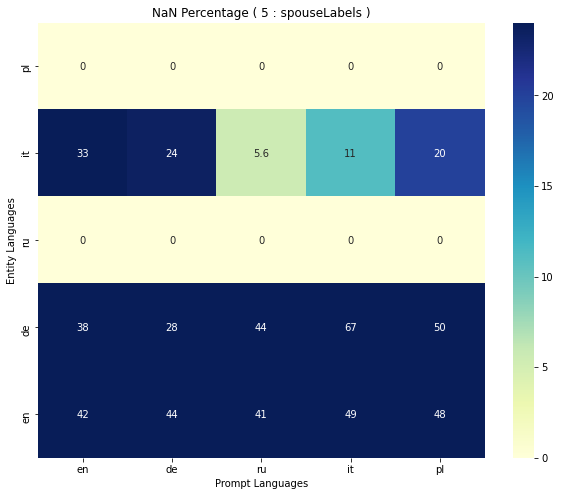

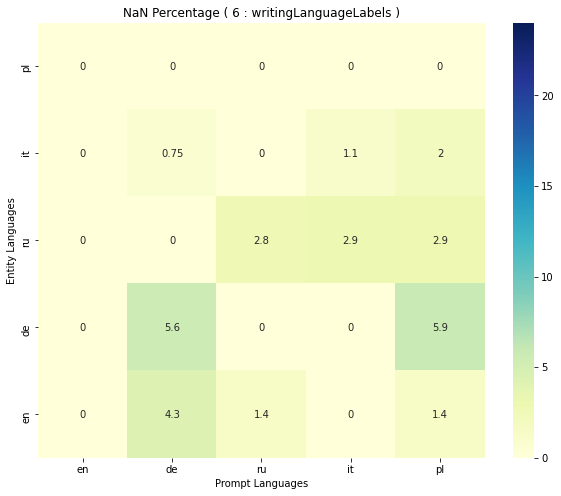

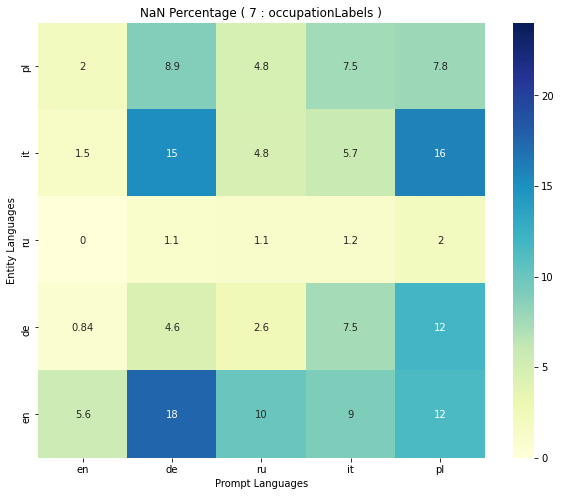

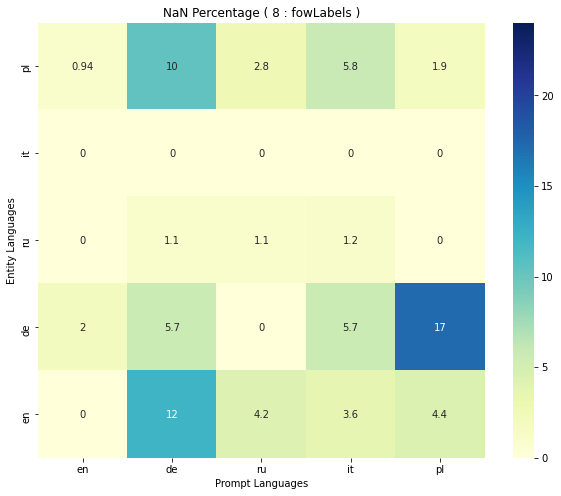

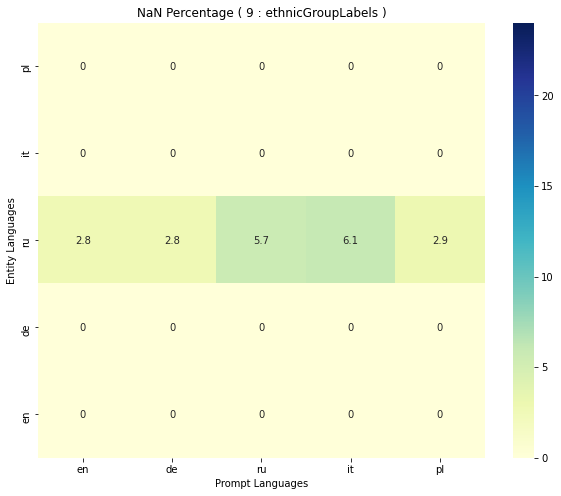

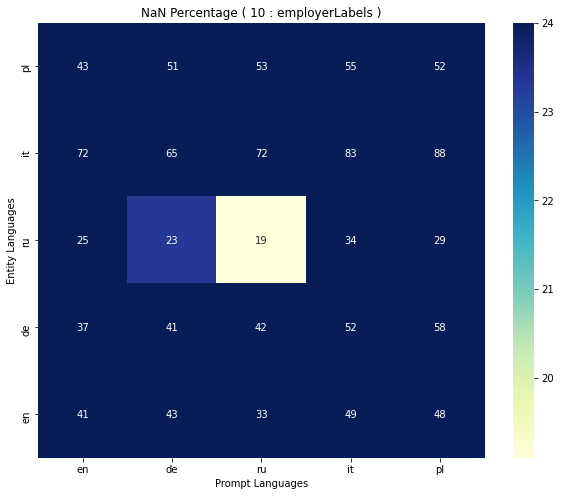

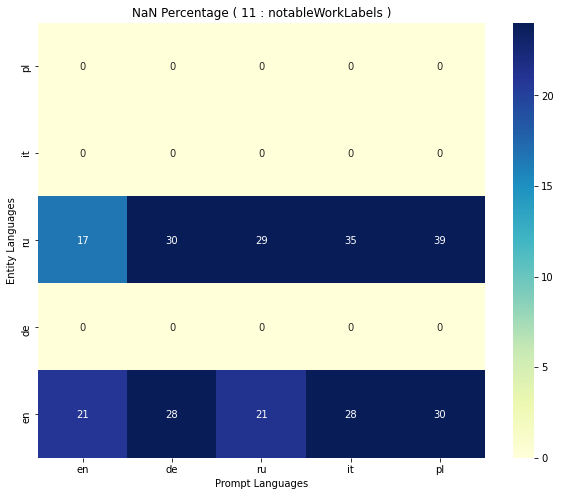

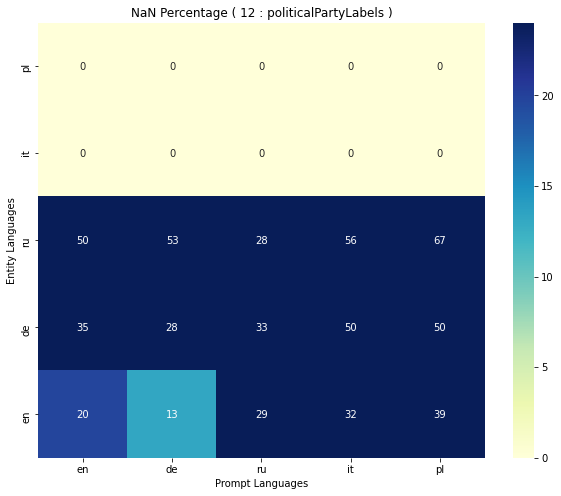

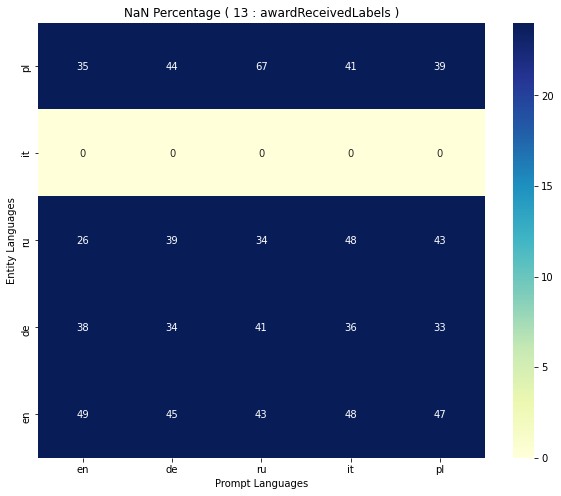

In [9]:
# Generate the heatmap for entity vs prompt languages (each question)
# "not available" means that the raw data from wiki have empty field (no ground truth) so we do not inference these questions.
# so 0 can be "not available" not 0 nan value 
for qid, nan_matrix_q in nan_matrix_question_based.items():
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(nan_matrix_q, annot=True, vmax=24, cmap="YlGnBu", xticklabels=prompt_languages, yticklabels=entity_languages)
    plt.title(f"NaN Percentage ( {qid} : { labels_dict[qid] } )")
    plt.xlabel("Prompt Languages")
    plt.ylabel("Entity Languages")

    # Show the heatmap
    plt.show()

## 1.3 NaN Values Analysis (entity based)

to be continued

# 2. In which language does the LLM tend to respond: prompt language or entity language? ( relevant for further evaluation )

The current entities' ground truths we have are available only in one language - entity language. The instruction part of the prompts include the rule - LLM should provive answers in the entity's (native) language. (to be discussed)

In [10]:
import fasttext
from collections import Counter

def most_common_value(lst):
    count = Counter(lst)
    return count.most_common(1)[0][0]

# Download model from the link below
# https://fasttext.cc/docs/en/language-identification.html
model = fasttext.load_model('/Users/adrian/lid.176.bin')
def detect_language(text):
    prediction = model.predict(text)
    lang = prediction[0][0].split('__label__')[-1]
    return lang

## 2.1 Answers' Language (Prompt) Analysis (model based)  

### score = count of the cases when LLM returns answer in the same language as the prompt question / total answers

We did not consider dates, names and 'N/A' into total answers

In [11]:
# score = count of the cases when LLM returns answer in the same language as XX / total answers
# XX -> 1) prompt language ; 2) entity language

# 1) collect answers's langauge information 'al_matrix' for global heatmap (loop over all the models / runs)
# 2) collect answers's langauge information 'al_matrix_model_based' for model heatmap (loop over all runs)
# heatmap (entity language x prompt language)

entity_languages = []
prompt_languages = []
num_langs = 5
# entity_languages = ['pl','it','ru','de','en']
# prompt_languages = ['en','de','ru','it','pl']
# Initialize a 5x5 matrix to hold percentages ( prompt language == answer language )
al_matrix = np.zeros((5, 5))
al_matrix_model_based = {}

# Loop through entity and prompt languages to calculate percentages
for i, entity_lang_path in enumerate(os.listdir(rootpath)):
    entity_language = entity_lang_path
    entity_languages.append(entity_language)

    for j, prompt_lang_path in enumerate(os.listdir(os.path.join(rootpath, entity_lang_path))):
        prompt_language = prompt_lang_path
        if i + j == num_langs - 1: prompt_languages.append(prompt_language)

        global_lang = 0
        global_total = 0
        
        # Loop through models and runs for the current entity and prompt language
        for model_name in os.listdir(os.path.join(rootpath, entity_lang_path, prompt_lang_path)):
            # Skip the folders that contain raw data
            if model_name in ['raw_data', 'merged']:
                continue
            
            # Initialize a 5x5 matrix to hold percentages for each model
            if model_name not in al_matrix_model_based:
                al_matrix_model_based[model_name] = np.zeros((5, 5))  
                
            lang = 0
            total = 0
            
            # Loop through runs. For the same entity & related questions, each model inference three times with do_sample=True and outputs (same/different) results.  
            for run in os.listdir(os.path.join(rootpath, entity_lang_path, prompt_lang_path, model_name)):
                run_id = int(run.split('_')[1])
            
                for results_file_path in os.listdir(os.path.join(rootpath, entity_lang_path, prompt_lang_path, model_name, run)):
                    try:
                        results_json = read_results_file(os.path.join(rootpath, entity_lang_path, prompt_lang_path, model_name, run, results_file_path))
                    except:
                        print(f"Could not read result file: {results_file_path}")
                        continue
                        
                    entity_id = results_file_path.split(".")[0].split("_")[0]
                    assert results_file_path.split(".")[0].split("_")[-1] == prompt_language
                    assert results_json['raw_data']['authorLabel']['xml:lang'] == entity_language
                    
                    for k, v in results_json['outputs'].items():
                        
                        # Skip certain questions, e.g. Birth Name, Date of Birth
                        if int(k) in [ results_json['raw_data']['birthNameLabels']['idx'] ]:
                            continue
                        if 'dob' in results_json['raw_data']:
                            if int(k) in [ results_json['raw_data']['dob']['idx'] ]:
                                continue
                            
                            
                        # Skip nan values
                        if isinstance(v, list):
                            if len(set(v)) == 1 and 'N/A' in v[0].strip():
                                continue
                        elif isinstance(v, str):
                            if 'N/A' in v.strip():
                                continue
                        else:
                            raise ValueError("The content is not string-based and list-based.")
                    
                        
                        if isinstance(v, list):
                            langs = [ detect_language(text.strip().replace('\n', '')) for text in v if 'N/A' != text ]
                            if len(langs) == 0:
                                continue
                                
                            total += 1
                            # if most_common_value(langs) == entity_language:
                            if most_common_value(langs) == prompt_language:
                                lang += 1
                        elif isinstance(v, str):
                            
                            total += 1
                            v = v.strip().replace('\n', '')
                            l = detect_language(v)
                            # if l == entity_language:
                            if l == prompt_language:
                                lang += 1
                        else:
                            raise ValueError("The content is not string-based and list-based.")
                            
            # (each model) Calculate percentage for the current entity and prompt language combination
            pct_lang = round((lang / total) * 100, 2)
            print(f"Percentage of answer in prompt language for entity {entity_language} - prompt {prompt_language} ( {model_name} ) : {pct_lang}%")
            al_matrix_model_based[model_name][i, num_langs - 1 - j] = pct_lang
        
            global_lang += lang
            global_total += total
            
        # Calculate percentage for the current entity and prompt language combination
        global_pct_lang = round((global_lang / global_total) * 100, 2)
        print(line_separator)
        print(f"Percentage of answer in prompt language for entity {entity_language} - prompt {prompt_language}: {global_pct_lang}%")
        print(line_separator)
        
        # Store the result in the matrix
        al_matrix[i, num_langs - 1 - j] = global_pct_lang

Percentage of answer in prompt language for entity pl - prompt pl ( llama3 ) : 85.89%
Percentage of answer in prompt language for entity pl - prompt pl ( gemma ) : 79.27%
Percentage of answer in prompt language for entity pl - prompt pl ( llama3_1_70b ) : 84.11%
Percentage of answer in prompt language for entity pl - prompt pl ( llama3_1 ) : 81.33%
Percentage of answer in prompt language for entity pl - prompt pl ( phi3_5 ) : 76.34%
Percentage of answer in prompt language for entity pl - prompt pl ( mistral ) : 71.7%
----------------------------------------------------------------------------------------------------
Percentage of answer in prompt language for entity pl - prompt pl: 79.87%
----------------------------------------------------------------------------------------------------
Percentage of answer in prompt language for entity pl - prompt it ( llama3 ) : 27.71%
Percentage of answer in prompt language for entity pl - prompt it ( gemma ) : 5.52%
Percentage of answer in prompt 

Percentage of answer in prompt language for entity ru - prompt ru ( llama3_1 ) : 90.37%
Percentage of answer in prompt language for entity ru - prompt ru ( phi3_5 ) : 81.97%
Percentage of answer in prompt language for entity ru - prompt ru ( mistral ) : 76.24%
----------------------------------------------------------------------------------------------------
Percentage of answer in prompt language for entity ru - prompt ru: 85.21%
----------------------------------------------------------------------------------------------------
Percentage of answer in prompt language for entity ru - prompt de ( llama3 ) : 21.93%
Percentage of answer in prompt language for entity ru - prompt de ( gemma ) : 1.02%
Percentage of answer in prompt language for entity ru - prompt de ( llama3_1_70b ) : 11.11%
Percentage of answer in prompt language for entity ru - prompt de ( llama3_1 ) : 48.19%
Percentage of answer in prompt language for entity ru - prompt de ( phi3_5 ) : 8.02%
Percentage of answer in prom

Percentage of answer in prompt language for entity en - prompt en ( gemma ) : 90.59%
Percentage of answer in prompt language for entity en - prompt en ( llama3_1_70b ) : 94.29%
Percentage of answer in prompt language for entity en - prompt en ( llama3_1 ) : 88.84%
Percentage of answer in prompt language for entity en - prompt en ( phi3_5 ) : 94.84%
Percentage of answer in prompt language for entity en - prompt en ( mistral ) : 95.05%
----------------------------------------------------------------------------------------------------
Percentage of answer in prompt language for entity en - prompt en: 91.95%
----------------------------------------------------------------------------------------------------


### 2.1.1 Answers' Language (Prompt) Information Global Heatmap 

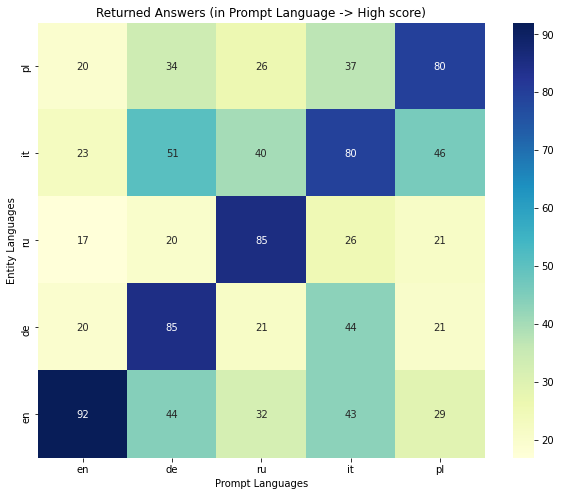

In [12]:
# Generate the heatmap for entity vs prompt languages (global)
plt.figure(figsize=(10, 8))
sns.heatmap(al_matrix, annot=True, cmap="YlGnBu", xticklabels=prompt_languages, yticklabels=entity_languages)
plt.title("Returned Answers (in Prompt Language -> High score)")
plt.xlabel("Prompt Languages")
plt.ylabel("Entity Languages")

# Show the heatmap
plt.show()

### 2.1.2 Answers' Language (Prompt) Information Model Heatmap

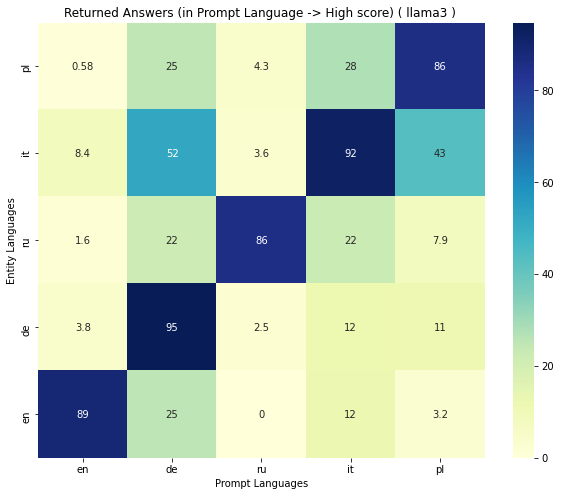

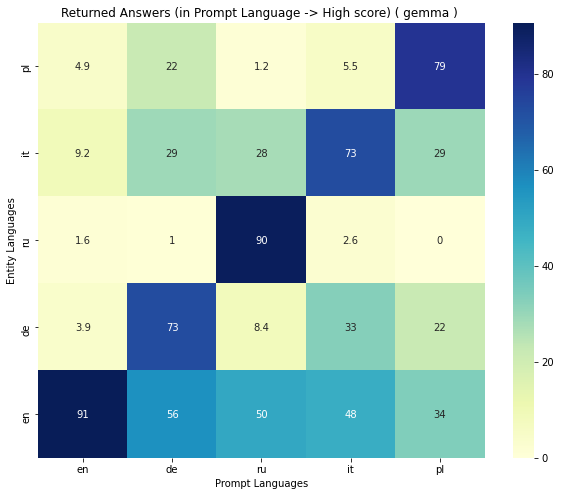

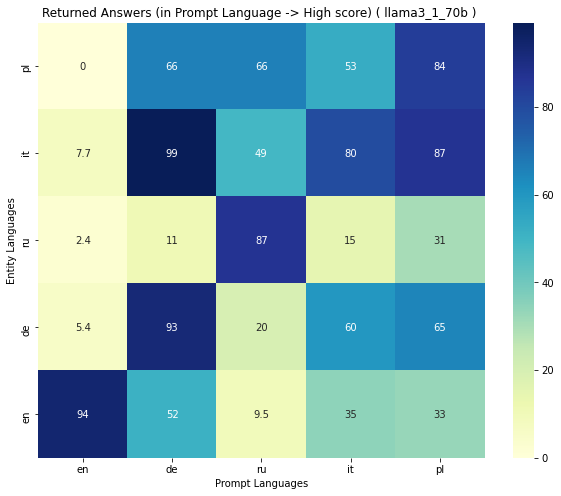

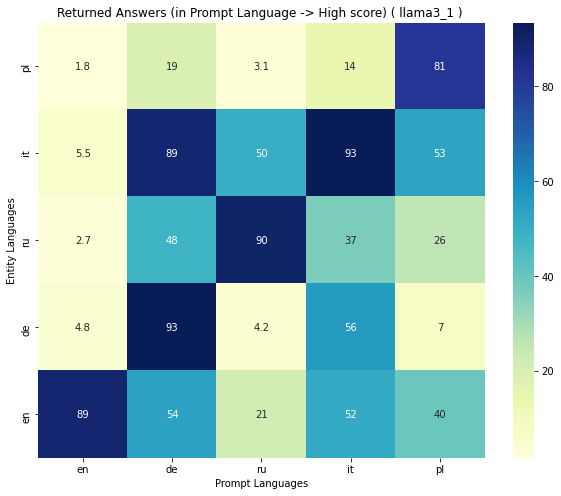

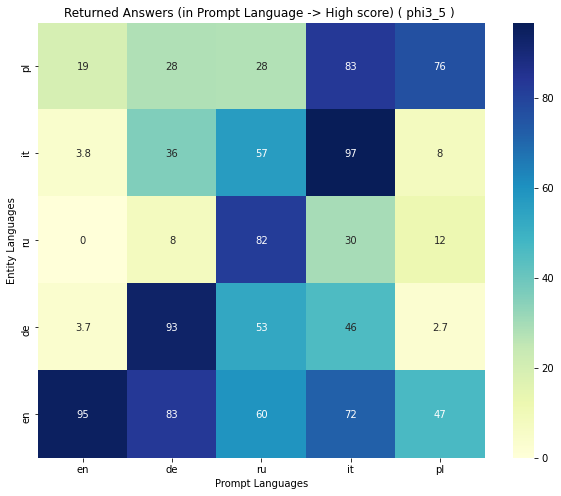

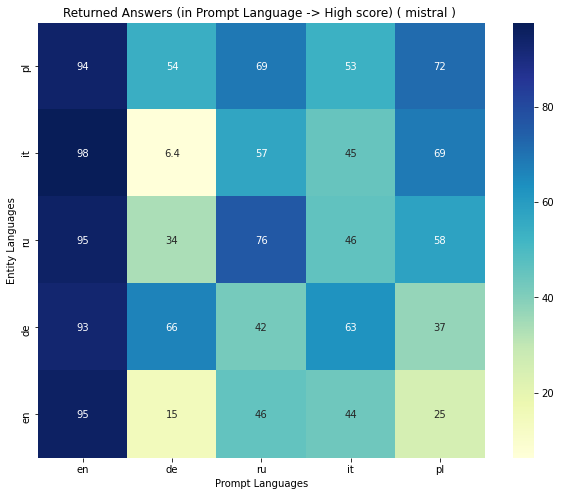

In [13]:
# Generate the heatmap for entity vs prompt languages (each model)
for model_name, al_matrix_m in al_matrix_model_based.items():

    plt.figure(figsize=(10, 8))
    sns.heatmap(al_matrix_m, annot=True, cmap="YlGnBu", xticklabels=prompt_languages, yticklabels=entity_languages)
    plt.title(f"Returned Answers (in Prompt Language -> High score) ( {model_name} ) ")
    plt.xlabel("Prompt Languages")
    plt.ylabel("Entity Languages")

    # Show the heatmap
    plt.show()

## 2.2 Answers' Language (Entity) Analysis (model based)  

### score = count of the cases when LLM returns answer in the same language as the entity native language / total answers

Since the current ground truths we have for entities are only available in one language - entity's language (authorlabels xml:lang), the score here will reflect on the reliability of our final evaluation results. Unless we also collect ground truths in different languages. (To be discussed)

In [14]:
# score = count of the cases when LLM returns answer in the same language as XX / total answers
# XX -> 1) prompt language ; 2) entity language

# 1) collect answers's langauge information 'al_matrix' for global heatmap (loop over all the models / runs)
# 2) collect answers's langauge information 'al_matrix_model_based' for model heatmap (loop over all runs)
# heatmap (entity language x prompt language)

entity_languages = []
prompt_languages = []
num_langs = 5
# entity_languages = ['pl','it','ru','de','en']
# prompt_languages = ['en','de','ru','it','pl']
# Initialize a 5x5 matrix to hold percentages ( prompt language == answer language )
al_matrix = np.zeros((5, 5))
al_matrix_model_based = {}

# Loop through entity and prompt languages to calculate percentages
for i, entity_lang_path in enumerate(os.listdir(rootpath)):
    entity_language = entity_lang_path
    entity_languages.append(entity_language)

    for j, prompt_lang_path in enumerate(os.listdir(os.path.join(rootpath, entity_lang_path))):
        prompt_language = prompt_lang_path
        if i + j == num_langs - 1: prompt_languages.append(prompt_language)

        global_lang = 0
        global_total = 0
        
        # Loop through models and runs for the current entity and prompt language
        for model_name in os.listdir(os.path.join(rootpath, entity_lang_path, prompt_lang_path)):
            # Skip the folders that contain raw data
            if model_name in ['raw_data', 'merged']:
                continue
            
            # Initialize a 5x5 matrix to hold percentages for each model
            if model_name not in al_matrix_model_based:
                al_matrix_model_based[model_name] = np.zeros((5, 5))  
                
            lang = 0
            total = 0
            
            # Loop through runs. For the same entity & related questions, each model inference three times with do_sample=True and outputs (same/different) results.  
            for run in os.listdir(os.path.join(rootpath, entity_lang_path, prompt_lang_path, model_name)):
                run_id = int(run.split('_')[1])
            
                for results_file_path in os.listdir(os.path.join(rootpath, entity_lang_path, prompt_lang_path, model_name, run)):
                    try:
                        results_json = read_results_file(os.path.join(rootpath, entity_lang_path, prompt_lang_path, model_name, run, results_file_path))
                    except:
                        print(f"Could not read result file: {results_file_path}")
                        continue
                        
                    entity_id = results_file_path.split(".")[0].split("_")[0]
                    assert results_file_path.split(".")[0].split("_")[-1] == prompt_language
                    assert results_json['raw_data']['authorLabel']['xml:lang'] == entity_language
                    
                    for k, v in results_json['outputs'].items():
                        
                        # Skip certain questions, e.g. Birth Name, Date of Birth
                        if int(k) in [ results_json['raw_data']['birthNameLabels']['idx'] ]:
                            continue
                        if 'dob' in results_json['raw_data']:
                            if int(k) in [ results_json['raw_data']['dob']['idx'] ]:
                                continue
                            
                            
                        # Skip nan values
                        if isinstance(v, list):
                            if len(set(v)) == 1 and 'N/A' in v[0].strip():
                                continue
                        elif isinstance(v, str):
                            if 'N/A' in v.strip():
                                continue
                        else:
                            raise ValueError("The content is not string-based and list-based.")
                    
                        
                        if isinstance(v, list):
                            langs = [ detect_language(text.strip().replace('\n', '')) for text in v if 'N/A' != text ]
                            if len(langs) == 0:
                                continue
                                
                            total += 1
                            if most_common_value(langs) == entity_language:
                            # if most_common_value(langs) == prompt_language:
                                lang += 1
                        elif isinstance(v, str):
                            
                            total += 1
                            v = v.strip().replace('\n', '')
                            l = detect_language(v)
                            if l == entity_language:
                            # if l == prompt_language:
                                lang += 1
                        else:
                            raise ValueError("The content is not string-based and list-based.")
                            
            # (each model) Calculate percentage for the current entity and prompt language combination
            pct_lang = round((lang / total) * 100, 2)
            print(f"Percentage of answer in entity language for entity {entity_language} - prompt {prompt_language} ( {model_name} ) : {pct_lang}%")
            al_matrix_model_based[model_name][i, num_langs - 1 - j] = pct_lang
        
            global_lang += lang
            global_total += total
            
        # Calculate percentage for the current entity and prompt language combination
        global_pct_lang = round((global_lang / global_total) * 100, 2)
        print(line_separator)
        print(f"Percentage of answer in entity language for entity {entity_language} - prompt {prompt_language}: {global_pct_lang}%")
        print(line_separator)
        
        # Store the result in the matrix
        al_matrix[i, num_langs - 1 - j] = global_pct_lang

Percentage of answer in entity language for entity pl - prompt pl ( llama3 ) : 85.89%
Percentage of answer in entity language for entity pl - prompt pl ( gemma ) : 79.27%
Percentage of answer in entity language for entity pl - prompt pl ( llama3_1_70b ) : 84.11%
Percentage of answer in entity language for entity pl - prompt pl ( llama3_1 ) : 81.33%
Percentage of answer in entity language for entity pl - prompt pl ( phi3_5 ) : 76.34%
Percentage of answer in entity language for entity pl - prompt pl ( mistral ) : 71.7%
----------------------------------------------------------------------------------------------------
Percentage of answer in entity language for entity pl - prompt pl: 79.87%
----------------------------------------------------------------------------------------------------
Percentage of answer in entity language for entity pl - prompt it ( llama3 ) : 51.2%
Percentage of answer in entity language for entity pl - prompt it ( gemma ) : 79.14%
Percentage of answer in entity 

Percentage of answer in entity language for entity ru - prompt pl ( phi3_5 ) : 55.93%
Percentage of answer in entity language for entity ru - prompt pl ( mistral ) : 0.0%
----------------------------------------------------------------------------------------------------
Percentage of answer in entity language for entity ru - prompt pl: 51.79%
----------------------------------------------------------------------------------------------------
Percentage of answer in entity language for entity ru - prompt it ( llama3 ) : 60.85%
Percentage of answer in entity language for entity ru - prompt it ( gemma ) : 80.83%
Percentage of answer in entity language for entity ru - prompt it ( llama3_1_70b ) : 76.24%
Percentage of answer in entity language for entity ru - prompt it ( llama3_1 ) : 33.71%
Percentage of answer in entity language for entity ru - prompt it ( phi3_5 ) : 57.14%
Percentage of answer in entity language for entity ru - prompt it ( mistral ) : 0.58%
------------------------------

Percentage of answer in entity language for entity en - prompt ru ( gemma ) : 43.8%
Percentage of answer in entity language for entity en - prompt ru ( llama3_1_70b ) : 80.69%
Percentage of answer in entity language for entity en - prompt ru ( llama3_1 ) : 67.02%
Percentage of answer in entity language for entity en - prompt ru ( phi3_5 ) : 17.12%
Percentage of answer in entity language for entity en - prompt ru ( mistral ) : 44.97%
----------------------------------------------------------------------------------------------------
Percentage of answer in entity language for entity en - prompt ru: 56.37%
----------------------------------------------------------------------------------------------------
Percentage of answer in entity language for entity en - prompt de ( llama3 ) : 68.59%
Percentage of answer in entity language for entity en - prompt de ( gemma ) : 34.23%
Percentage of answer in entity language for entity en - prompt de ( llama3_1_70b ) : 46.74%
Percentage of answer in 

### 2.2.1 Answers' Language (Entity) Information Global Heatmap 

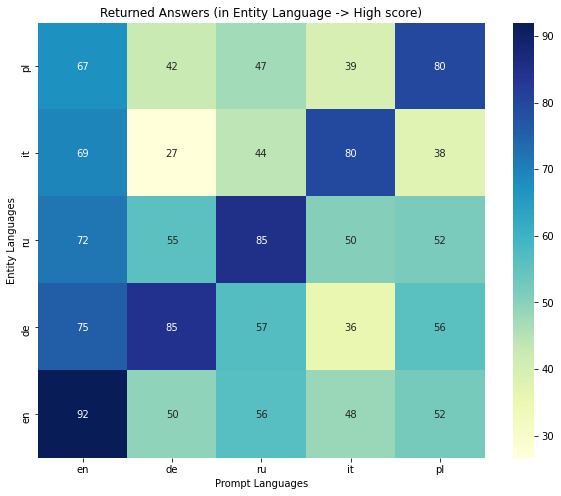

In [15]:
# Generate the heatmap for entity vs prompt languages (global)
plt.figure(figsize=(10, 8))
sns.heatmap(al_matrix, annot=True, cmap="YlGnBu", xticklabels=prompt_languages, yticklabels=entity_languages)
plt.title("Returned Answers (in Entity Language -> High score)")
plt.xlabel("Prompt Languages")
plt.ylabel("Entity Languages")

# Show the heatmap
plt.show()

### 2.2.2 Answers' Language (Entity) Information Model Heatmap 

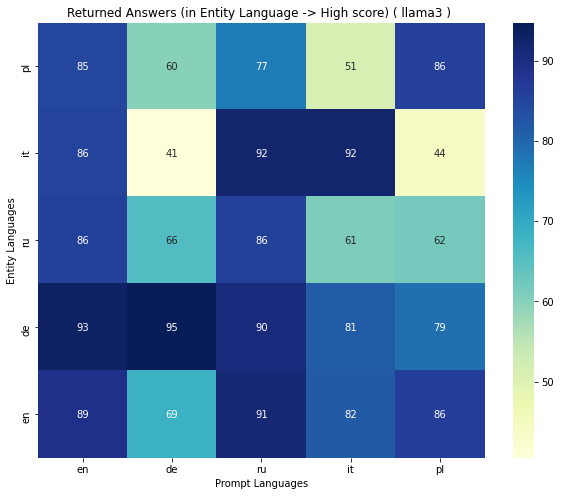

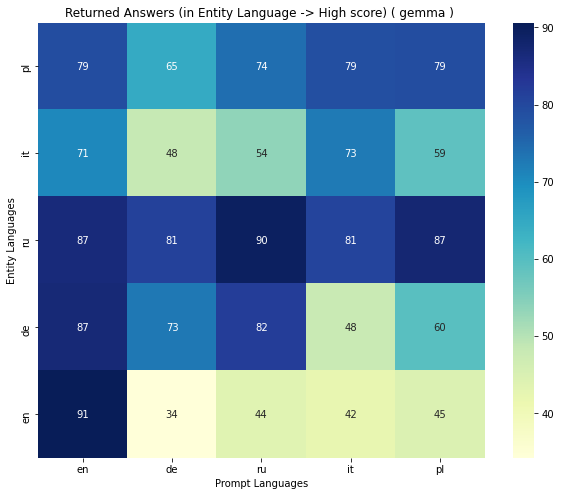

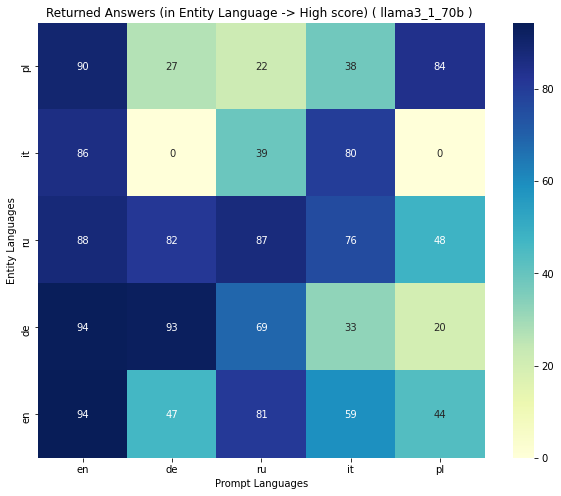

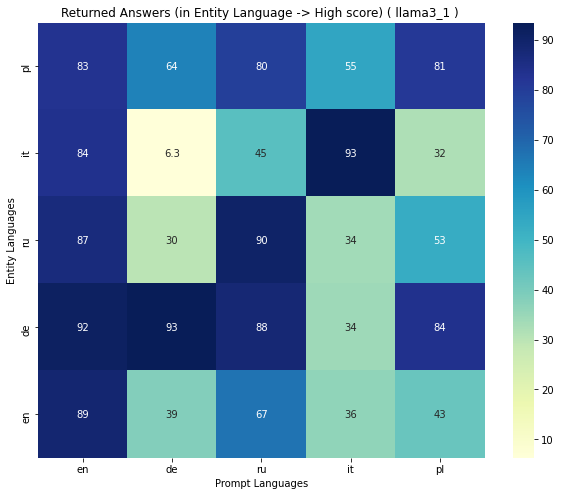

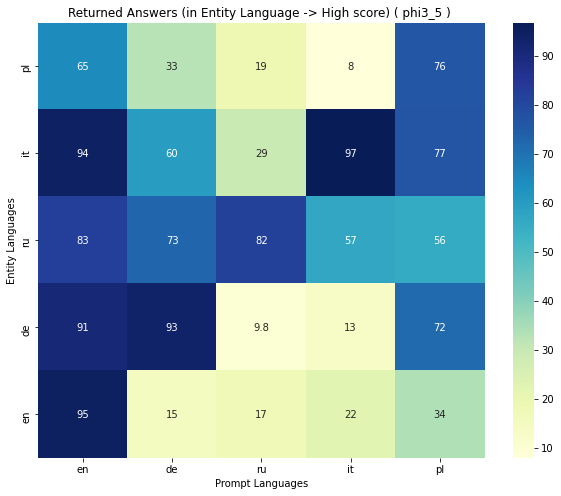

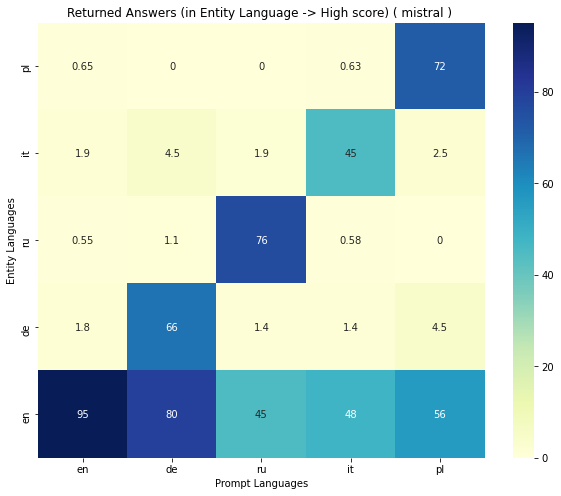

In [16]:
# Generate the heatmap for entity vs prompt languages (each model)
for model_name, al_matrix_m in al_matrix_model_based.items():

    plt.figure(figsize=(10, 8))
    sns.heatmap(al_matrix_m, annot=True, cmap="YlGnBu", xticklabels=prompt_languages, yticklabels=entity_languages)
    plt.title(f"Returned Answers (in Entity Language -> High score) ( {model_name} ) ")
    plt.xlabel("Prompt Languages")
    plt.ylabel("Entity Languages")

    # Show the heatmap
    plt.show()

## 2.3 & 2.4 Answers' Language Analysis (question based & entity based)  

To be continue 

# 3 How accurate are the answers provided by the LLM? 

This part may be inaccurate, due to
- the fuzzy search does not cover things with the same meaning; 
    e.g., the Kingdom of Netherlands vs. Netherlands; USA vs. America 
- the language misalignment between answers and ground truths;
    e.g., Germany vs. Niemcy

## 3.1 Evaluation - Accuracy (question based)

In [17]:
import re
import pycountry
from rapidfuzz import fuzz, utils

In [18]:
# given prediction, ground truth, question id, return boolean value 
def is_gt(v, gt, qid):
    
    # 1. date of birth       - dob
    if qid == 1:
    
        if isinstance(v, list):
            prediction = [ 
                re.search(r'\b(\d{4})\b', str(s)).group(1) 
                for s in v if re.search(r'\b(\d{4})\b', str(s))
            ]
        if isinstance(v, str):
            prediction = re.search(r'\b(\d{4})\b', str(v)).group(1) 
            
        if len(prediction) == 0:
            return False
        else:
            prediction = prediction[0]

        if prediction == gt[:4]:
            return True
        else:
            return False
        
    # 3. birth name          - birthNameLabels
    # 5. spouse name         - spouseLabels
    if qid in [3, 5]:
        
        if isinstance(v, list):
            prediction = ' '.join([ text for text in v if text != 'N/A'])
        if isinstance(v, str):
            prediction = v
        
        if prediction == gt:
            return True
        elif fuzz.ratio(prediction, gt) > 85:
            return True
        elif fuzz.token_set_ratio(prediction, gt) > 90:
            # print (gt, '|', prediction)
            return True
        elif fuzz.token_sort_ratio(prediction, gt) > 90:
            # print (gt, '|', prediction)
            return True
        else:
            return False 
        
    # 4. country name        - countryLabels
    if qid == 4: 
        
        if isinstance(v, list):
            prediction = [ text for text in v if text != 'N/A'][0].strip() 
        if isinstance(v, str):
            prediction = v.strip() 
        
        if len(gt.split(',')) == 2:
            gt = gt.split(',')[1]
        
        gt = gt.strip() 
        
        if prediction == gt:
            return True
        if detect_language(prediction) == 'en' and detect_language(gt) == 'en':
            try:
                if pycountry.countries.search_fuzzy(prediction) == pycountry.countries.search_fuzzy(gt):
                    return True
            except:
                return False
        return False
        
    # 6. language            - writingLanguageLabels
    if qid == 6:
        if isinstance(v, list):
            prediction = v[0]
        if isinstance(v, str):
            prediction = v
            
        if fuzz.ratio(gt, prediction) > 85:
            return True
        elif fuzz.partial_ratio(gt, prediction) > 90:
            return True
        elif fuzz.token_set_ratio(gt, prediction) > 90:
            return True
        elif fuzz.token_sort_ratio(gt, prediction) > 90:
            return True
        else:
            return False
        
    # 9. ethnic group        - ethnicGroupLabels
    if qid == 9:
        if isinstance(v, list):
            prediction = v[0]
        if isinstance(v, str):
            prediction = v
        
        if prediction == gt:
            return True
        else:
            return False
        
    # 10. employer           - employerLabels
    if qid == 10:
        if isinstance(v, list):
            if gt in v:
                return True
            else:
                return False

        if isinstance(v, str):
            if gt == v:
                return True
            else:
                return False
            
    # 2. place of birth      - pob  
    # 7. occupation          - occupationLabels
    # 8. field of work       - fowLabels
    # 11. notable work       - notableWorkLabels
    # 12. politicalParty     - politicalPartyLabels
    # 13. award              - awardReceivedLabels
    if qid in [2, 7, 8, 11, 12, 13]:
        for gt_item in gt.split(','): 
            if isinstance(v, list):
                for prediction in v:
                    if fuzz.ratio(gt_item, prediction) > 85:
                        return True
                    elif fuzz.partial_ratio(gt_item, prediction) > 90:
                        return True
                    elif fuzz.token_set_ratio(gt_item, prediction) > 90:
                        return True
                    elif fuzz.token_sort_ratio(gt_item, prediction) > 90:
                        return True
                    else:
                        return False
            if isinstance(v, str):
                prediction = v 
                if fuzz.ratio(gt_item, prediction) > 85:
                    return True
                elif fuzz.partial_ratio(gt_item, prediction) > 90:
                    return True
                elif fuzz.token_set_ratio(gt_item, prediction) > 90:
                    return True
                elif fuzz.token_sort_ratio(gt_item, prediction) > 90:
                    return True
                else:
                    return False

In [19]:
entity_languages = []
prompt_languages = []
num_langs = 5
num_questions = 13
# misalignments from raw data exist, some entities do not include 'dob'
labels_dict = {1: 'dob', 2: 'pobLabels', 3: 'birthNameLabels', 4: 'countryLabels', 5: 'spouseLabels', 6: 'writingLanguageLabels', 7: 'occupationLabels', 8: 'fowLabels', 9: 'ethnicGroupLabels', 10: 'employerLabels', 11: 'notableWorkLabels', 12: 'politicalPartyLabels', 13: 'awardReceivedLabels'}
# Initialize 5x5 matrices to hold NaN percentages for each question 
acc_matrix = np.zeros((5, 5))
acc_matrix_question_based = { qid + 1 : np.zeros((5, 5)) for qid in range(num_questions)} 

# Loop through entity and prompt languages to calculate NaN percentages
for i, entity_lang_path in enumerate(os.listdir(rootpath)):
    entity_language = entity_lang_path
    entity_languages.append(entity_language)

    for j, prompt_lang_path in enumerate(os.listdir(os.path.join(rootpath, entity_lang_path))):
        prompt_language = prompt_lang_path
        if i + j == num_langs - 1: prompt_languages.append(prompt_language)

        global_eval = 0
        global_total = 0
        
        tmp_dict = { qid + 1 : {'total': 0, 'hit': 0} for qid in range(num_questions)}
        
        # Loop through models and runs for the current entity and prompt language
        for model_name in os.listdir(os.path.join(rootpath, entity_lang_path, prompt_lang_path)):
            # Skip the folders that contain raw data
            if model_name in ['raw_data', 'merged']:
                continue 
            
            # Loop through runs. For the same entity & related questions, each model inference three times with do_sample=True and outputs (same/different) results.  
            for run in os.listdir(os.path.join(rootpath, entity_lang_path, prompt_lang_path, model_name)):
                run_id = int(run.split('_')[1])
            
                for results_file_path in os.listdir(os.path.join(rootpath, entity_lang_path, prompt_lang_path, model_name, run)):
                    try:
                        results_json = read_results_file(os.path.join(rootpath, entity_lang_path, prompt_lang_path, model_name, run, results_file_path))
                    except:
                        print(f"Could not read result file: {results_file_path}")
                        continue
                        
                    entity_id = results_file_path.split(".")[0].split("_")[0]
                    assert results_file_path.split(".")[0].split("_")[-1] == prompt_language
                    assert results_json['raw_data']['authorLabel']['xml:lang'] == entity_language
                     
                    # Different than the global one, same idx may refer to different things in different entities'raw json files 
                    tmp_label_dict = { value['idx'] : label for label, value in results_json['raw_data'].items()}
                    
                    for idx, v in results_json['outputs'].items():
                        
                        # Skip nan values
                        if isinstance(v, list):
                            if len(set(v)) == 1 and 'N/A' in v[0].strip():
                                continue
                        elif isinstance(v, str):
                            if 'N/A' in v.strip():
                                continue
                        else:
                            raise ValueError("The content is not string-based and list-based.")
                        
                        # Align the global label dict and the current file
                        qid = None
                        idx = int(idx)
                        label = tmp_label_dict[idx]
                        for key, value in labels_dict.items():
                            if value == label:
                                qid = key
                        
                        tmp_dict[qid]['total'] += 1
                        gt = results_json['raw_data'][label]['value'] 
                        if is_gt(v, gt, qid):
                            tmp_dict[qid]['hit'] += 1

                            
        # pprint.pprint(tmp_dict)            
        for qid, v in tmp_dict.items():
            
            acc = round((tmp_dict[qid]['hit'] / tmp_dict[qid]['total']) * 100, 2) if tmp_dict[qid]['total'] > 0 else 0
            acc_matrix_question_based[qid][i, num_langs - 1 - j] = acc
            
            if tmp_dict[qid]['total'] != 0:
                print(f"Accuracy - entity {entity_language} - prompt {prompt_language} - {qid:2} {labels_dict[qid]:23}: {acc:6}%  ")
            else:
                print(f"Accuracy - entity {entity_language} - prompt {prompt_language} - {qid:2} {labels_dict[qid]:23}: {acc:6}% (not available)")

        global_acc = sum(v['hit'] for qid, v in tmp_dict.items())
        global_total = sum(v['total'] for qid, v in tmp_dict.items())

        # Calculate percentage of NaN values for the current entity and prompt language combination
        global_acc = round((global_acc / global_total) * 100, 2)
        print(line_separator)
        print(f"Accuracy - entity {entity_language} - prompt {prompt_language}: {global_acc}%")
        print(line_separator)

        # Store the result in the matrix
        acc_matrix[i, num_langs - 1 - j] = global_acc

Accuracy - entity pl - prompt pl -  1 dob                    :   1.97%  
Accuracy - entity pl - prompt pl -  2 pobLabels              :   8.54%  
Accuracy - entity pl - prompt pl -  3 birthNameLabels        :    0.0%  
Accuracy - entity pl - prompt pl -  4 countryLabels          :  89.94%  
Accuracy - entity pl - prompt pl -  5 spouseLabels           :      0% (not available)
Accuracy - entity pl - prompt pl -  6 writingLanguageLabels  :  83.33%  
Accuracy - entity pl - prompt pl -  7 occupationLabels       :    0.0%  
Accuracy - entity pl - prompt pl -  8 fowLabels              :    0.0%  
Accuracy - entity pl - prompt pl -  9 ethnicGroupLabels      :      0% (not available)
Accuracy - entity pl - prompt pl - 10 employerLabels         :   7.84%  
Accuracy - entity pl - prompt pl - 11 notableWorkLabels      :      0% (not available)
Accuracy - entity pl - prompt pl - 12 politicalPartyLabels   :      0% (not available)
Accuracy - entity pl - prompt pl - 13 awardReceivedLabels    :    0.

Accuracy - entity it - prompt de -  1 dob                    :   0.62%  
Accuracy - entity it - prompt de -  2 pobLabels              :   2.63%  
Accuracy - entity it - prompt de -  3 birthNameLabels        :      0% (not available)
Accuracy - entity it - prompt de -  4 countryLabels          :   1.64%  
Accuracy - entity it - prompt de -  5 spouseLabels           :    0.0%  
Accuracy - entity it - prompt de -  6 writingLanguageLabels  :  31.18%  
Accuracy - entity it - prompt de -  7 occupationLabels       :   1.01%  
Accuracy - entity it - prompt de -  8 fowLabels              :      0% (not available)
Accuracy - entity it - prompt de -  9 ethnicGroupLabels      :      0% (not available)
Accuracy - entity it - prompt de - 10 employerLabels         :    0.0%  
Accuracy - entity it - prompt de - 11 notableWorkLabels      :      0% (not available)
Accuracy - entity it - prompt de - 12 politicalPartyLabels   :      0% (not available)
Accuracy - entity it - prompt de - 13 awardReceivedLab

Accuracy - entity de - prompt pl -  1 dob                    :    3.8%  
Accuracy - entity de - prompt pl -  2 pobLabels              :   1.84%  
Accuracy - entity de - prompt pl -  3 birthNameLabels        :      0% (not available)
Accuracy - entity de - prompt pl -  4 countryLabels          :  33.41%  
Accuracy - entity de - prompt pl -  5 spouseLabels           :    0.0%  
Accuracy - entity de - prompt pl -  6 writingLanguageLabels  :   37.5%  
Accuracy - entity de - prompt pl -  7 occupationLabels       :   2.11%  
Accuracy - entity de - prompt pl -  8 fowLabels              :    0.0%  
Accuracy - entity de - prompt pl -  9 ethnicGroupLabels      :      0% (not available)
Accuracy - entity de - prompt pl - 10 employerLabels         :    0.0%  
Accuracy - entity de - prompt pl - 11 notableWorkLabels      :      0% (not available)
Accuracy - entity de - prompt pl - 12 politicalPartyLabels   :    0.0%  
Accuracy - entity de - prompt pl - 13 awardReceivedLabels    :    0.0%  
---------

Accuracy - entity en - prompt ru -  1 dob                    :  13.74%  
Accuracy - entity en - prompt ru -  2 pobLabels              :  11.03%  
Accuracy - entity en - prompt ru -  3 birthNameLabels        :  41.96%  
Accuracy - entity en - prompt ru -  4 countryLabels          :   4.89%  
Accuracy - entity en - prompt ru -  5 spouseLabels           :  11.46%  
Accuracy - entity en - prompt ru -  6 writingLanguageLabels  :  64.79%  
Accuracy - entity en - prompt ru -  7 occupationLabels       :   6.11%  
Accuracy - entity en - prompt ru -  8 fowLabels              :  18.38%  
Accuracy - entity en - prompt ru -  9 ethnicGroupLabels      :      0% (not available)
Accuracy - entity en - prompt ru - 10 employerLabels         :   2.82%  
Accuracy - entity en - prompt ru - 11 notableWorkLabels      :  26.13%  
Accuracy - entity en - prompt ru - 12 politicalPartyLabels   :    9.8%  
Accuracy - entity en - prompt ru - 13 awardReceivedLabels    :    2.0%  
-------------------------------------

### 3.1.1 Evaluation Accuracy Global Heatmap 

The comparisons among languages across all questions are not entirely fair, as the total number of inferred questions for each language pair varies. For example, some fields in the Polish-Polish (pl * pl) pair were not considered because no ground truths were provided. 

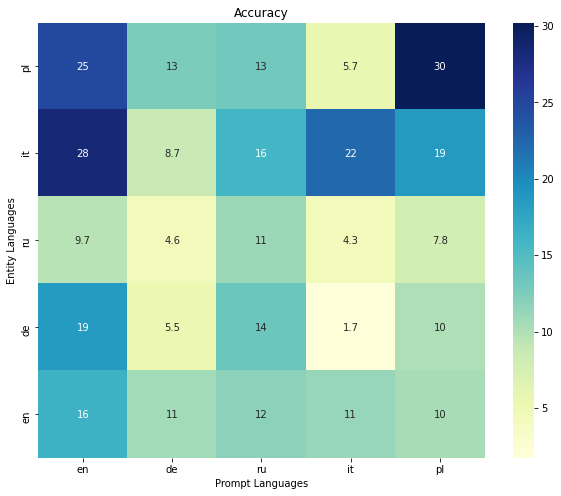

In [20]:
# Generate the heatmap for entity vs prompt languages (global)
plt.figure(figsize=(10, 8))
sns.heatmap(acc_matrix, annot=True, cmap="YlGnBu", xticklabels=prompt_languages, yticklabels=entity_languages)
plt.title("Accuracy")
plt.xlabel("Prompt Languages")
plt.ylabel("Entity Languages")

# Show the heatmap
plt.show()

### 3.1.2 Evaluation Accuracy Heatmap (questions based)

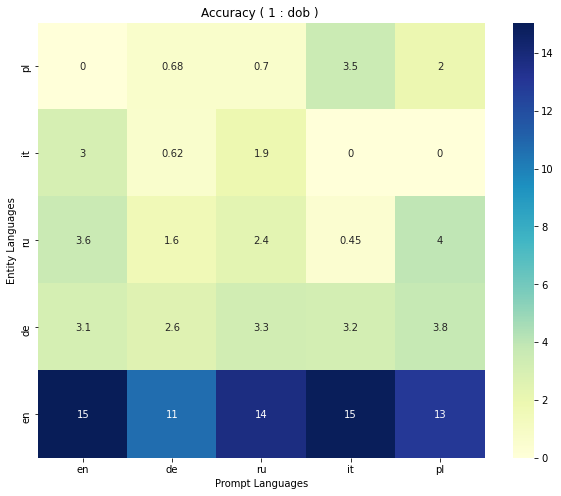

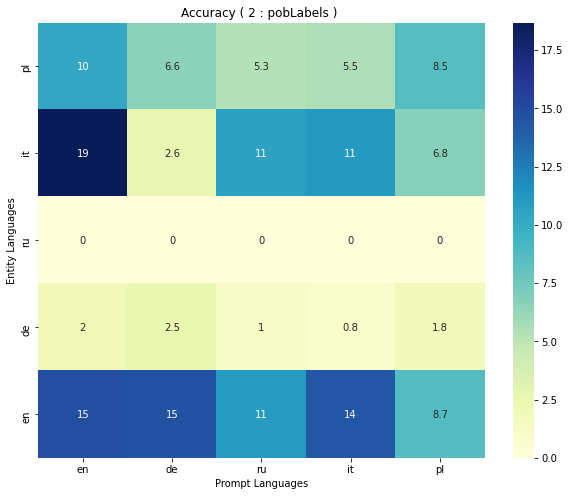

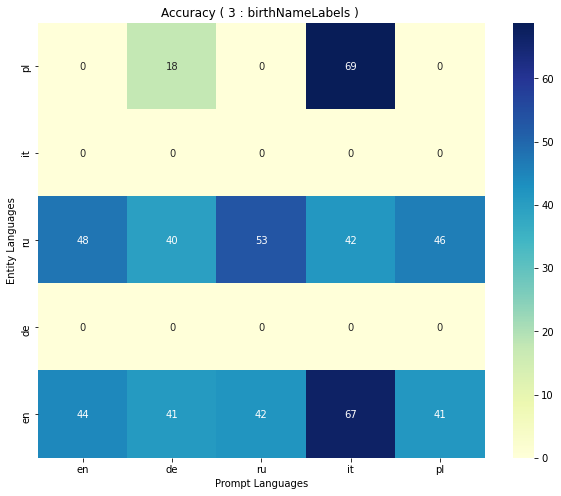

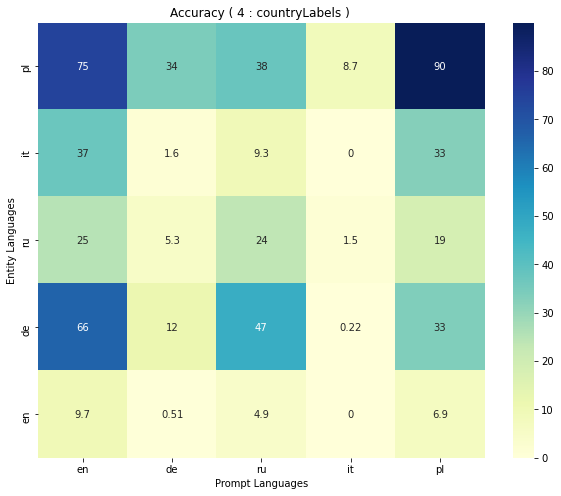

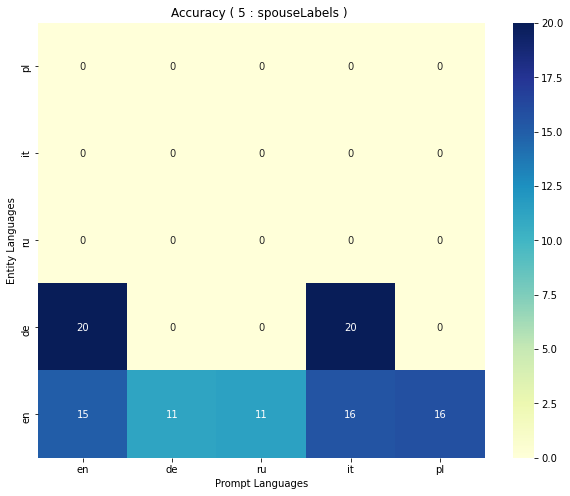

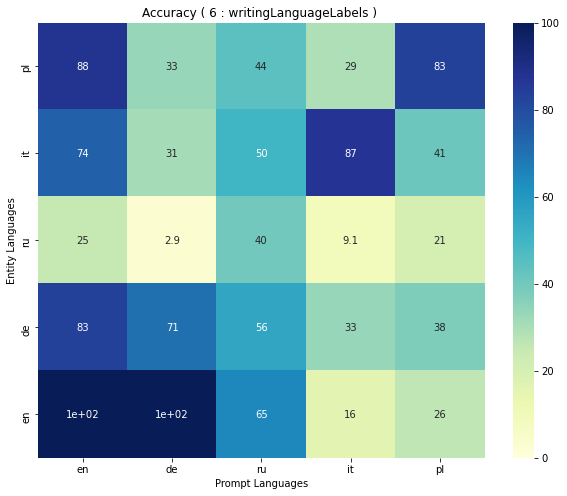

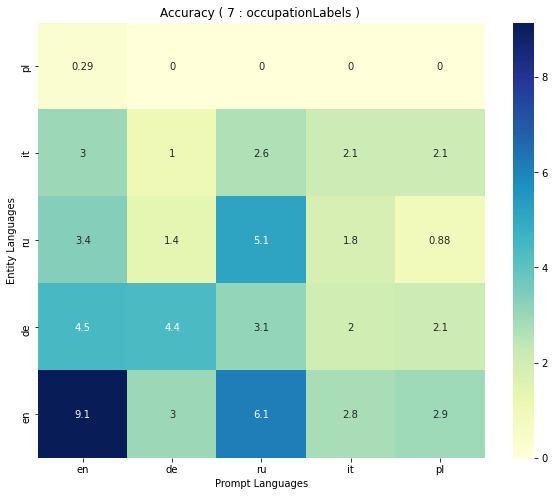

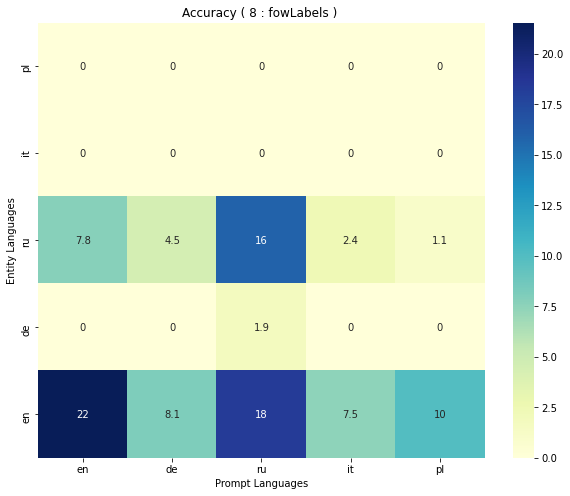

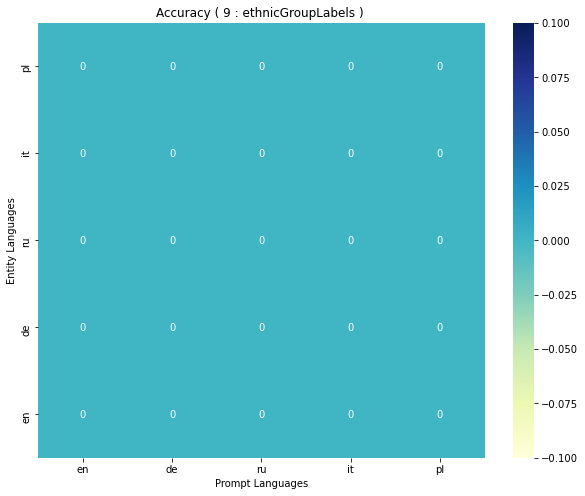

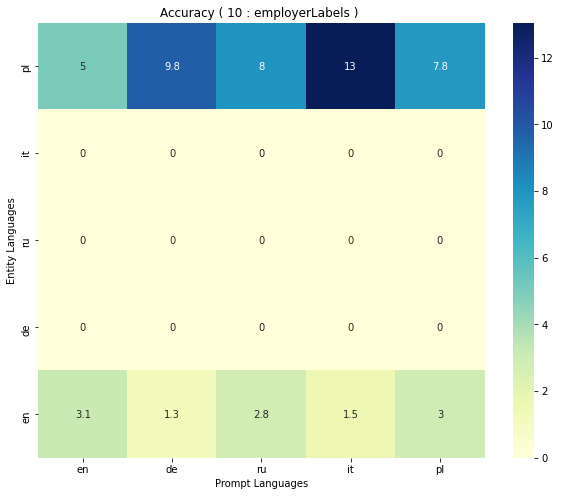

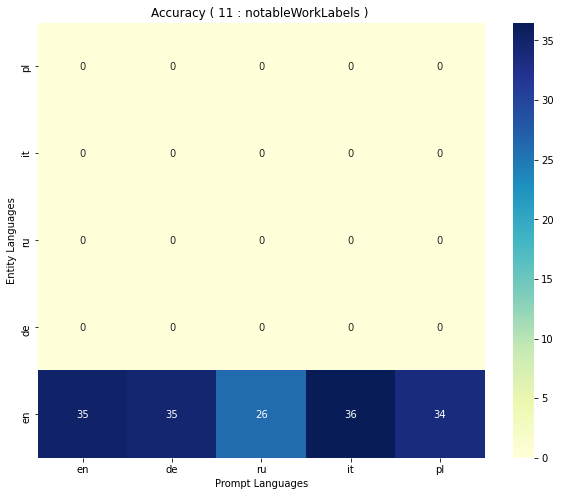

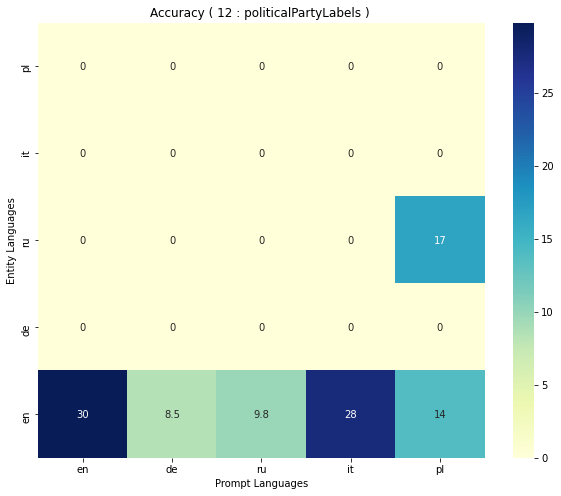

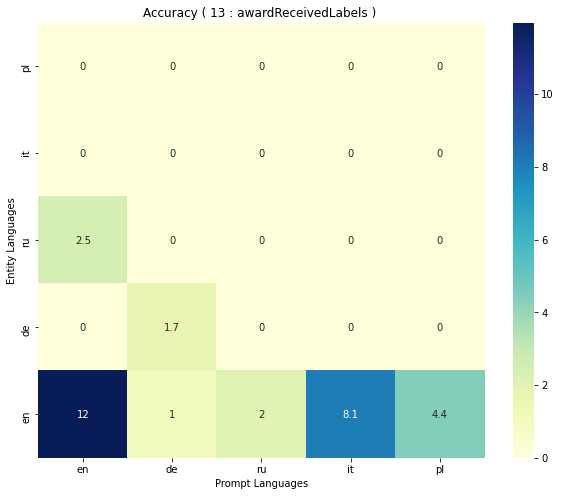

In [21]:
# Generate the heatmap for entity vs prompt languages (each question)
for qid, acc_matrix_q in acc_matrix_question_based.items():

    plt.figure(figsize=(10, 8))
    sns.heatmap(acc_matrix_q, annot=True, vmin = 0, cmap="YlGnBu", xticklabels=prompt_languages, yticklabels=entity_languages)
    plt.title(f"Accuracy ( {qid} : { labels_dict[qid] } ) ")
    plt.xlabel("Prompt Languages")
    plt.ylabel("Entity Languages")

    # Show the heatmap
    plt.show()